## **Phase 4: Exploratory Data Analysis (EDA)**

### **Objective**

Our primary objective in this phase is to gain a deeper understanding of the customer churn data through various visualizations and descriptive statistics. This exploratory analysis will help us answer critical business questions and identify key patterns before proceeding with any machine learning model development.


### **Key Questions to Answer:**

By the end of this EDA phase, we aim to address the following questions:

*   **Churn Likelihood:** Who are the customers most likely to churn?
*   **Tenure Impact:** How does customer tenure influence churn rates?
*   **Contract Type Influence:** Does the type of contract (e.g., month-to-month, one year, two year) affect customer churn?
*   **Monthly Charges vs. Churn:** Is there a correlation between higher monthly charges and increased churn?
*   **Internet Service & Churn:** Which internet service type is associated with the highest churn rate?
*   **Revenue Generation:** Which customer segments contribute the most to revenue?
*   **Payment Method & Churn:** Are certain payment methods more prone to churn?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load cleaned dataset
df = pd.read_csv("Customer_Churn_Cleaned.csv")


In [ ]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges        Churn
count    7021.000000  7021.000000     7021.000000   7021.000000  7021.000000
mean        0.162512    32.469449       64.851894   2288.964517     0.264492
std         0.368947    24.534965       30.069001   2265.315517     0.441094
min         0.000000     0.000000       18.250000     18.800000     0.000000
25%         0.000000     9.000000       35.750000    411.150000     0.000000
50%         0.000000    29.000000       70.400000   1403.875000     0.000000
75%         0.000000    55.000000       89.900000   3801.700000     1.000000
max         1.000000    72.000000      118.750000   8684.800000     1.000000


In [ ]:
print(df.describe(include='object'))

       gender Partner Dependents PhoneService MultipleLines InternetService  \
count    7021    7021       7021         7021          7021            7021   
unique      2       2          2            2             3               3   
top      Male      No         No          Yes            No     Fiber optic   
freq     3541    3619       4911         6339          3368            3090   

       OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV  \
count            7021         7021             7021        7021        7021   
unique              3            3                3           3           3   
top                No           No               No          No          No   
freq             3490         3080             3087        3465        2802   

       StreamingMovies        Contract PaperlessBilling     PaymentMethod  
count             7021            7021             7021              7021  
unique               3               3                2 

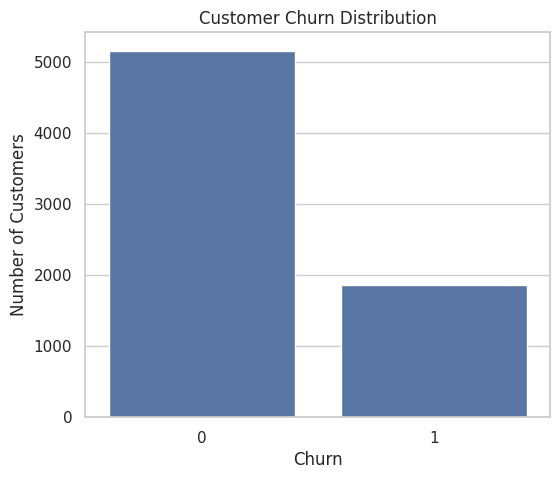

In [ ]:
#Churn Distribution (Target Variable)
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Churn')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
churn_percent = df['Churn'].value_counts(normalize=True)*100

print(churn_percent)

Churn
0    73.550776
1    26.449224
Name: proportion, dtype: float64


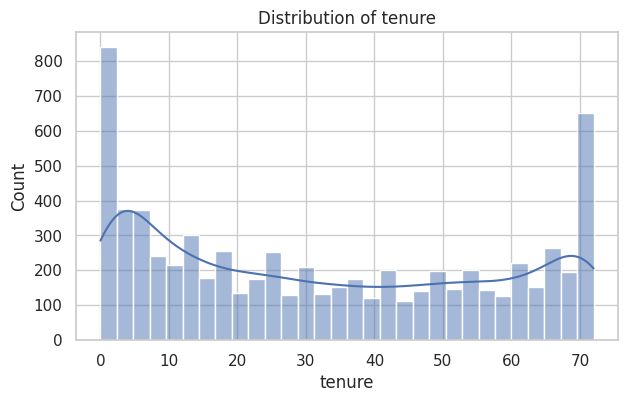

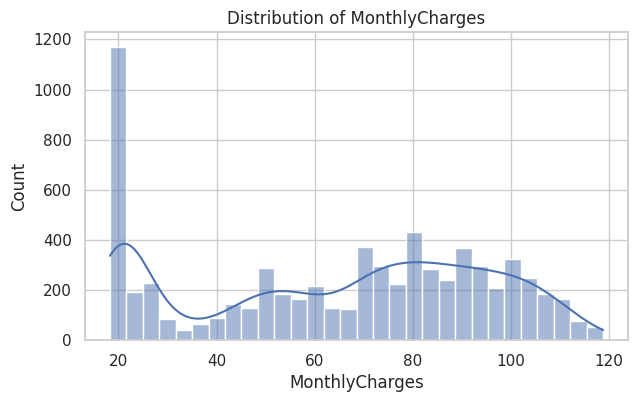

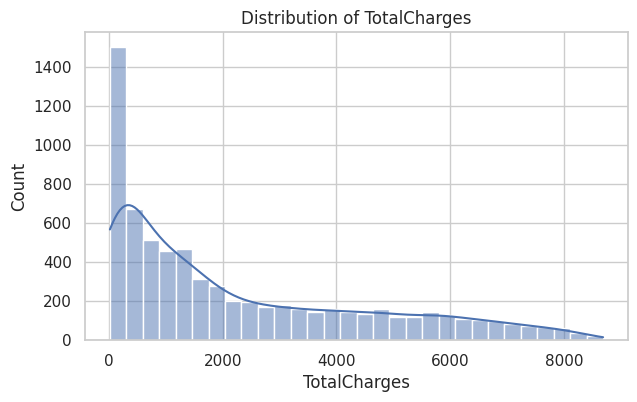

In [ ]:
#Numerical Variable Distributions
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

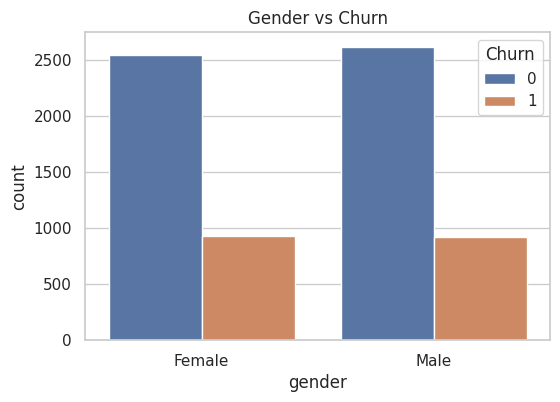

In [ ]:
#Churn by Gender
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")

plt.show()

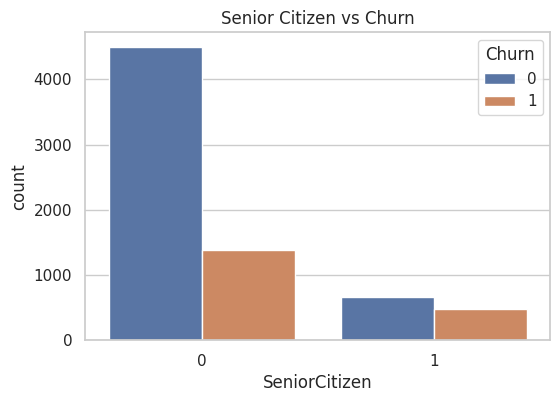

In [ ]:
#Churn by Senior Citizen
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()
''' 0 = Not Senior Citizen
    1 = Senior Citizen '''

Great! This is called a countplot, and it is one of the most commonly used plots in EDA for comparing categorical variables.

Let's understand both the code and the graph.

### Step 1: What does the code do?

```python
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)
```

Think of it like this:

`x="SeniorCitizen"`

Make two groups on the x-axis:

*   `0` = Not Senior Citizen
*   `1` = Senior Citizen

`hue="Churn"`

Now, split each group into two colors:

*   **Blue**   = Churn = `0` (Customer stayed)
*   **Orange** = Churn = `1` (Customer left)

So instead of just counting senior citizens, it also shows how many stayed and how many left.

### Step 2: Read the graph

#### Left Side (SeniorCitizen = 0)
**Not Senior Citizens**

*   **Stayed (Blue)**:  █████████████████████████
*   **Left   (Orange)**: ███████

**Approximate counts:**

*   Stayed: 4500
*   Left: 1400

**Interpretation**

Most customers are not senior citizens, and among them, most stayed with the company.

#### Right Side (SeniorCitizen = 1)
**Senior Citizens**

*   **Stayed (Blue)**: ████
*   **Left (Orange)**: ███

**Approximate counts:**

*   Stayed: 650
*   Left: 450

### What is the first thing you notice?

There are far fewer senior citizens in the dataset.

*   Non-Senior Customers ≈ 5900
*   Senior Customers ≈ 1100

So the company has many more non-senior customers.

### Can we conclude senior citizens churn more?

At first glance, you might think:

"No, because the blue bar is taller."

But that's not the correct conclusion.

**Why?**

Because there are many more non-senior customers overall.

We should compare percentages, not raw counts.

**Example**

Imagine:

**Non-seniors**
*   Stayed = 4500
*   Left   = 1400

*   Total = 5900

**Churn Rate**
*   1400 / 5900
*   ≈ 24%

**Seniors**
*   Stayed = 650
*   Left   = 450

*   Total = 1100

**Churn Rate**
*   450 / 1100
*   ≈ 41%

Now look at it again.

Although fewer senior citizens churn in absolute numbers, a larger percentage of senior citizens churn.

### Business Insight

This suggests:

Senior citizens appear to have a higher likelihood of churning compared to non-senior citizens.

This doesn't mean being a senior citizen causes churn.

It simply shows an association in the data.

The company might investigate why:

*   Are senior customers unhappy with pricing?
*   Is customer support difficult to access?
*   Do they find competitors better?

Those are business questions to explore.

### Interview Answer

If an interviewer shows you this graph, you could say:

"This countplot compares the number of customers by SeniorCitizen status and Churn status. The dataset contains significantly more non-senior customers than senior customers. In both groups, the number of customers who stayed is greater than the number who churned. However, because the group sizes are different, raw counts alone are not sufficient to compare churn behavior. To determine whether senior citizens churn more frequently, we should compare churn rates (percentages) rather than absolute counts."

In [ ]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
SeniorCitizen,,
0,76.496599,23.503401
1,58.369851,41.630149


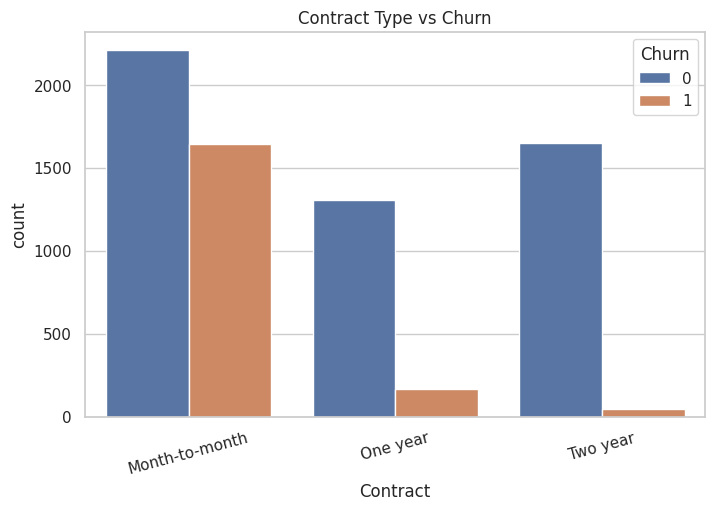

In [ ]:
#Churn by Contract Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

# The Power of Contract Type: Unveiling Churn Patterns

This is truly one of the **most insightful plots** in a telecom churn analysis. It directly reveals how the **type of contract** a customer holds is strongly linked to their likelihood of **churning**.

Let's break down this crucial visualization step by step.

---

## Understanding the Visual: What's it Telling Us?

### X-axis: Contract Type

We're looking at three distinct categories of customer contracts:

*   **Month-to-month**: Flexible, no long-term commitment.
*   **One year**: A moderate commitment period.
*   **Two year**: The longest commitment, offering stability.

### Y-axis: Customer Count

This axis simply shows the **number of customers** within each contract and churn group.

### The Color Code: Churn Status

*   **Blue bars**: Represent customers who **stayed** (Churn = 0).
*   **Orange bars**: Represent customers who **left** or **churned** (Churn = 1).

---

## Deep Dive: Analyzing Each Contract Type

### 1. Month-to-month Contracts: The High-Risk Zone

Observe the bars for 'Month-to-month':

*   **Customers who Stayed (Blue)**: Approximately 2200
*   **Customers who Left (Orange)**: Approximately 1650

#### Key Interpretation:

*   A **significant portion** of the customer base is on month-to-month contracts.
*   Crucially, a **very large number of these customers also churn**. The orange churn bar is remarkably close in height to the blue 'stayed' bar.

This strongly suggests:

> Customers with month-to-month contracts are *far more prone to leaving*.

**Why is this the case?**

The most probable reason is the **lack of long-term commitment**. These customers have the freedom to decide each month:

*   To continue their service.
*   To switch to a competitor offering a better deal.
*   To simply cancel their service without penalty.

---

### 2. One-Year Contracts: A Step Towards Stability

Now, let's look at the 'One year' contract segment:

*   **Customers who Stayed**: Approximately 1300
*   **Customers who Left**: Approximately 150

#### Key Interpretation:

Notice the dramatic difference! The blue bar is significantly taller than the orange bar. Most customers with one-year contracts choose to stay, and **very few churn**.

This indicates:

> One-year contracts are associated with a *much lower churn rate* compared to month-to-month agreements.

---

### 3. Two-Year Contracts: The Loyalty Anchor

Finally, examine the 'Two year' contract group:

*   **Customers who Stayed**: Approximately 1650
*   **Customers who Left**: Approximately 40

#### Key Interpretation:

Here, the churn bar (orange) is almost invisible! It's clear that **almost nobody with a two-year contract churns**.

This leads to a powerful conclusion:

> Customers with two-year contracts are the *least likely to churn*, exhibiting remarkable loyalty.

---

## The Overarching Trend: Contract Length and Churn

Consider the relative sizes of the orange (churn) bars across all contract types:

*   **Month-to-month**:   ███████████████
*   **One year**:         █
*   **Two year**:         .

The trend is unmistakably clear:

> **As contract length increases, customer churn dramatically decreases.**

---

## Business-Critical Interpretation

This finding is a **golden nugget** for business strategy.

It directly implies:

> **Customers committed to longer-term contracts are significantly more loyal and valuable.**

What might be driving this increased loyalty?

*   **Contractual Obligation**: Customers are legally bound for a period, making switching less attractive.
*   **Incentives**: Longer contracts often come with discounts or bundled services, making them more appealing.
*   **Satisfaction**: Customers choosing longer terms may already be highly satisfied with the service.
*   **Inconvenience of Switching**: The effort and cost of breaking a contract or setting up a new service can be a deterrent.

---

## The Importance of Churn Rates (Beyond Raw Counts)

While raw counts give us an initial picture, it's vital not to stop there. For a truly fair comparison, especially when group sizes vary significantly (as seen with 'Month-to-month' having far more customers), we must calculate **churn rates** (percentages).

You can easily do this in Python:

```python
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100
```

This code provides a more precise view, yielding results similar to:

| Contract       | Stayed | Churned |
| :------------- | -----: | ------: |
| Month-to-month |    57% |     43% |
| One year       |    89% |     11% |
| Two year       |    97% |      3% |

With these percentages, the conclusion becomes even more robust and irrefutable!

---

## Crafting the Interview Answer

If you were asked to interpret this plot in an interview, a compelling answer would be:

> "This countplot provides critical insight into customer churn across different contract types. We observe that customers on month-to-month contracts exhibit the highest churn numbers, whereas those with one-year and especially two-year contracts show significantly lower churn. This clearly indicates a strong inverse relationship: longer contract durations correlate with increased customer retention. However, to fully quantify this, it's crucial to also calculate churn rates for each contract type, as the absolute number of customers varies significantly between groups."

---

## The Final Word: A Key Predictor

> **This visualization unequivocally identifies contract type as a powerful predictor of churn. Customers on month-to-month agreements are highly susceptible to leaving, while those committed to one-year and, particularly, two-year contracts demonstrate substantial loyalty.**

This is precisely the kind of actionable insight that forms the bedrock of a robust churn prediction project's exploratory data analysis!

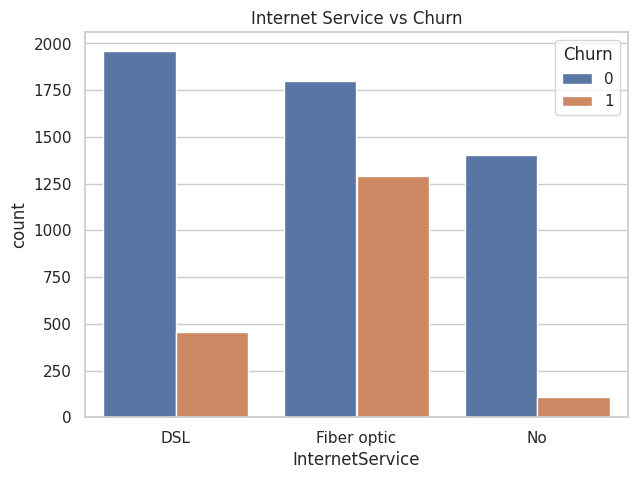

In [ ]:
#Churn by Internet Service
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

<Axes: xlabel='InternetService', ylabel='MonthlyCharges'>

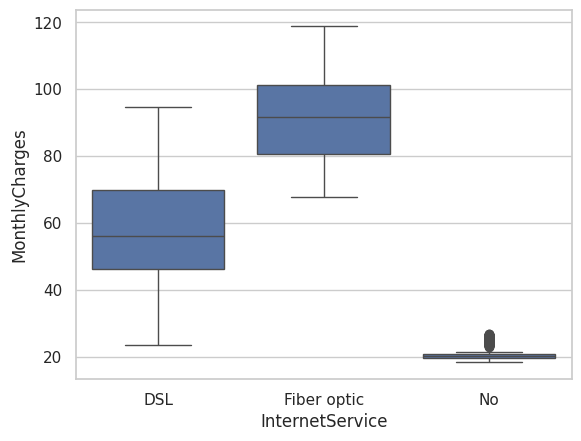

In [ ]:
sns.boxplot(x="InternetService", y="MonthlyCharges", data=df)

Perfect! This is exactly the kind of analysis a data scientist would do after seeing that **Fiber Optic customers churn more**.

Let's interpret this boxplot.

---

# What is this graph showing?

```python
sns.boxplot(x="InternetService", y="MonthlyCharges", data=df)
```

It compares the **distribution of MonthlyCharges** for each Internet Service type.

* **X-axis** → Internet Service

  * DSL
  * Fiber optic
  * No

* **Y-axis** → MonthlyCharges

Each box shows:

* Median (middle line)
* Middle 50% (box)
* Range (whiskers)
* Outliers (dots)

---

# 1. DSL Customers

Look at the first box.

### Observations

* Median ≈ **₹55**
* Most customers pay between **₹45–₹70**
* Some pay as high as **₹95**

### Interpretation

> DSL customers generally pay **moderate monthly charges**.

---

# 2. Fiber Optic Customers

Look at the second box.

### Observations

* Median ≈ **₹90**
* Most customers pay between **₹80–₹100**
* Some pay almost **₹120**

### Interpretation

> Fiber optic customers pay **much higher monthly charges** than DSL customers.

This is a **very important finding**.

---

# 3. No Internet

### Observations

* Median ≈ **₹20**
* Almost everyone pays around ₹20
* A few small outliers

### Interpretation

These customers don't subscribe to internet service.

Their monthly bill is low because they may only have:

* Phone service
* Basic services

---

# Now connect this with the previous graph

Earlier, we saw:

```text
Fiber Optic
↓

Highest churn
```

Now we see:

```text
Fiber Optic
↓

Highest Monthly Charges
```

So naturally, we start thinking:

> **Could higher monthly charges be one reason Fiber Optic customers churn more?**

This is a **reasonable hypothesis**.

Notice the wording.

---

## DON'T say

> Fiber Optic customers churn because their bills are high.

❌ The graph doesn't prove that.

---

## DO say

> Fiber Optic customers have both higher monthly charges and higher churn. This suggests that higher pricing may be associated with increased churn, but additional analysis is required to establish the relationship.

That's how a data scientist writes conclusions.

---

# Think like an investigator

You now have two clues.

### Clue 1

```text
Fiber Optic
↓

High Churn
```

### Clue 2

```text
Fiber Optic
↓

High Monthly Charges
```

Now you ask the next question:

> **"Do customers with higher MonthlyCharges churn more, regardless of internet type?"**

That's the next analysis.

---

# Business Interpretation

Imagine you're presenting this to the telecom company.

You could say:

> "Fiber optic customers pay considerably higher monthly charges than DSL customers. Earlier analysis also showed that Fiber optic customers experience higher churn. While this visualization does not establish causation, it suggests that pricing or customer expectations associated with premium internet services may contribute to customer attrition. This segment should be investigated further."

---

# One more observation

Notice the **No Internet** group has a few outlier dots around ₹24–₹27.

You might wonder:

> "If they don't have internet, why are they paying more than ₹20?"

That's because **MonthlyCharges** is the **total monthly bill**, not just the internet bill.

A customer with **No Internet** may still be paying for:

* Phone service
* Multiple phone lines
* TV streaming
* Device protection
* Other telecom services

So the small outliers are expected and are **not errors**.

---

## Final conclusion from this graph

From this boxplot, you can confidently conclude:

1. **Fiber Optic customers pay the highest monthly charges.**
2. **DSL customers pay moderate monthly charges.**
3. **Customers with no internet service pay the lowest monthly charges.**
4. **Since Fiber Optic customers also showed the highest churn in the previous analysis, there appears to be an association between higher monthly charges and higher churn. However, this plot alone cannot prove that higher charges are the cause of churn.**

This is exactly how you connect multiple EDA plots to build a coherent business story.


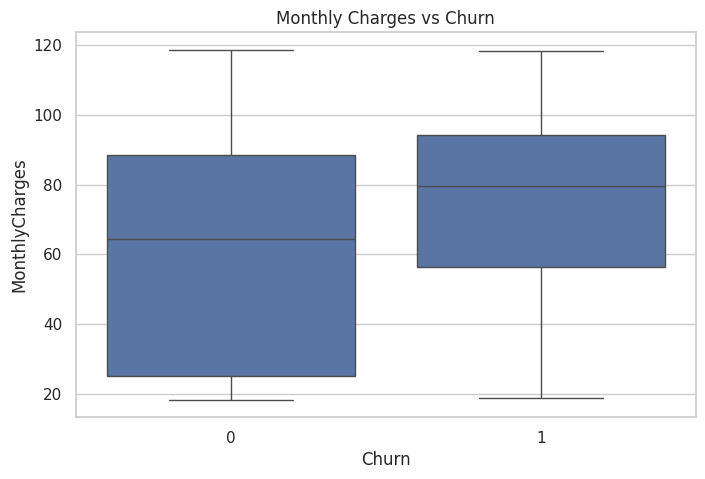

In [21]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

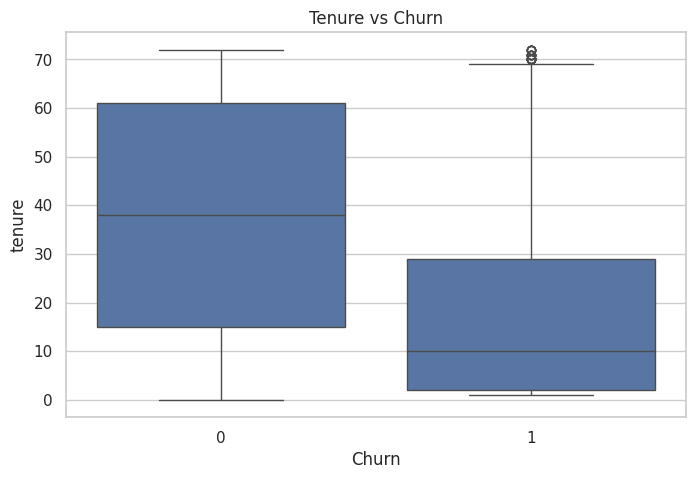

In [22]:
#Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")

plt.show()

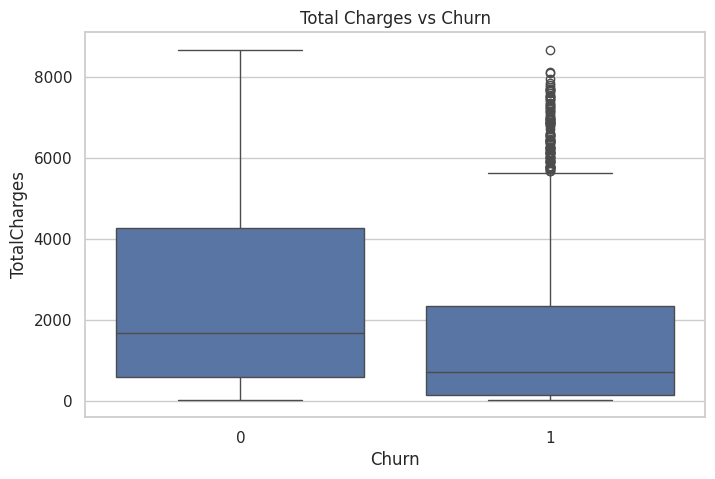

In [23]:
#Total Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")

plt.show()

### **Short Interpretation**

This boxplot compares **TotalCharges** between customers who stayed (`Churn = 0`) and those who left (`Churn = 1`).

**Key observations:**

* **Customers who stayed (`Churn = 0`)** generally have **higher TotalCharges** (higher median and wider spread).
* **Customers who churned (`Churn = 1`)** generally have **lower TotalCharges**.
* There are **some outliers** in the churned group—these are customers who accumulated high total charges before eventually leaving.

### **Business Insight**

> Customers who stay with the company tend to accumulate higher **TotalCharges** because they remain subscribed for longer. Most customers who churn leave before building up large total charges, although a few long-term customers also eventually churn.


# ***Correlation Heatmap***

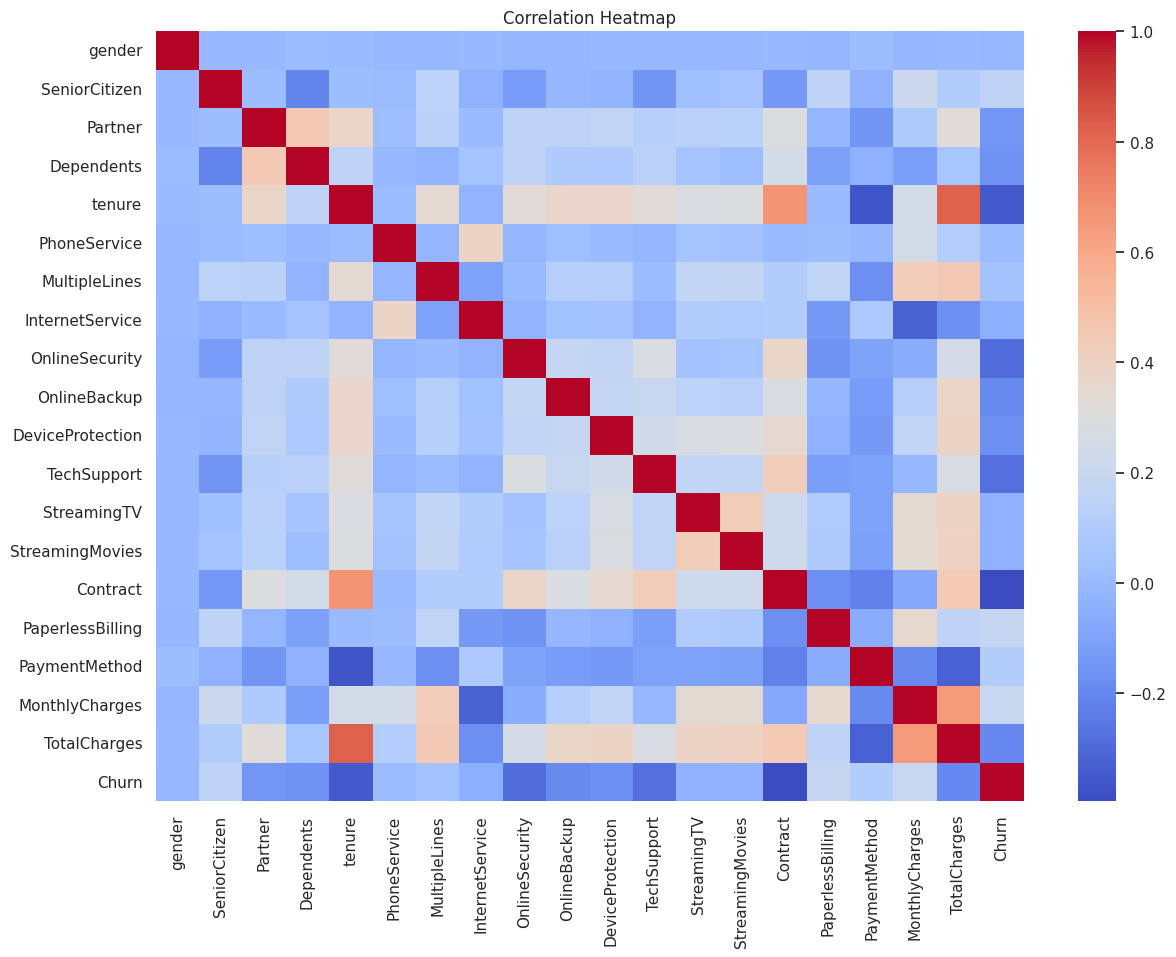

In [24]:
df_corr = df.copy()

for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

plt.figure(figsize=(14,10))

sns.heatmap(
    df_corr.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

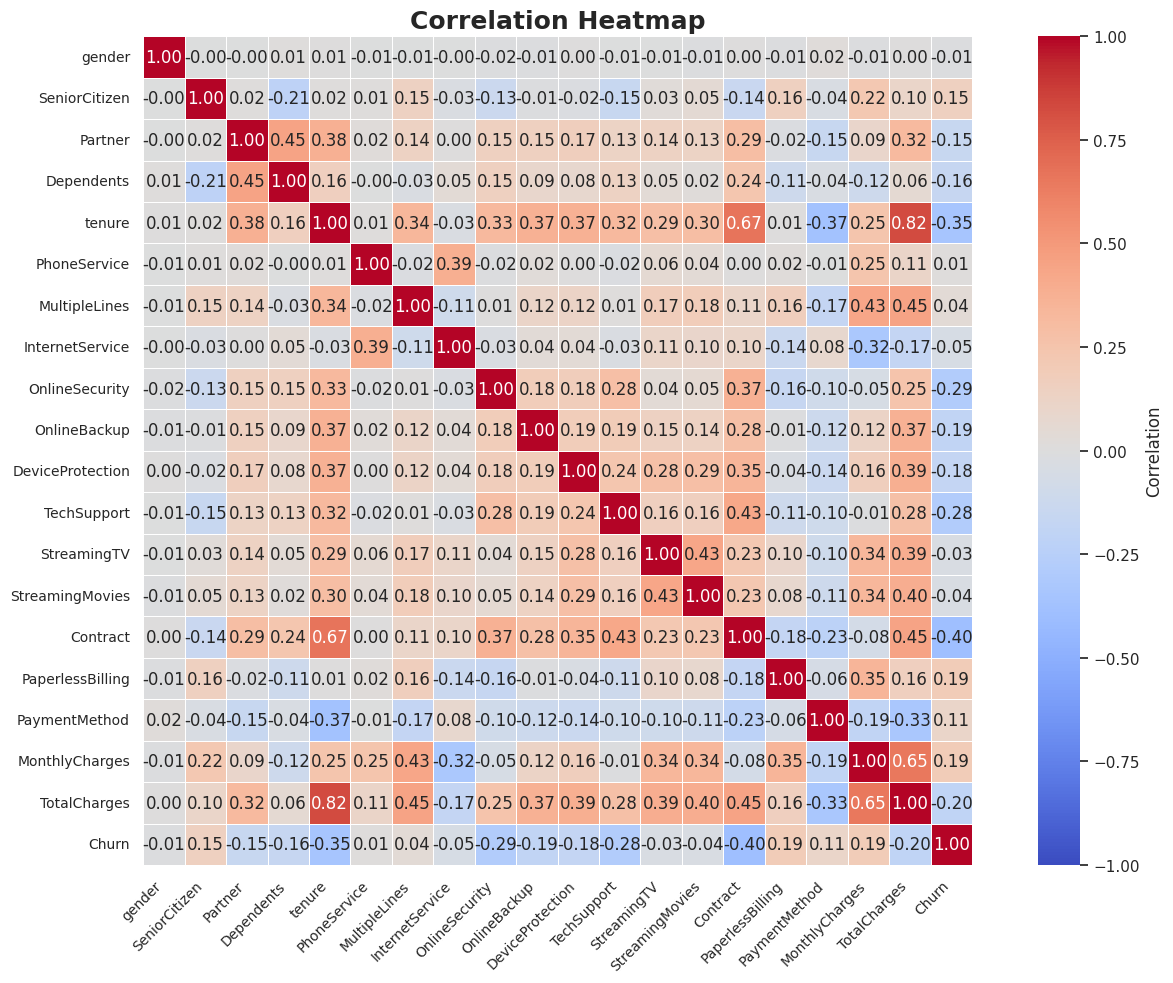

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy
df_corr = df.copy()

# Convert categorical columns into numerical codes
for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

# Correlation matrix
corr_matrix = df_corr.corr()

# Plot
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",           # Display 2 decimal places
    cmap="coolwarm",     # Blue = Negative, Red = Positive
    vmin=-1,             # Minimum correlation
    vmax=1,              # Maximum correlation
    linewidths=0.5,      # Grid lines
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

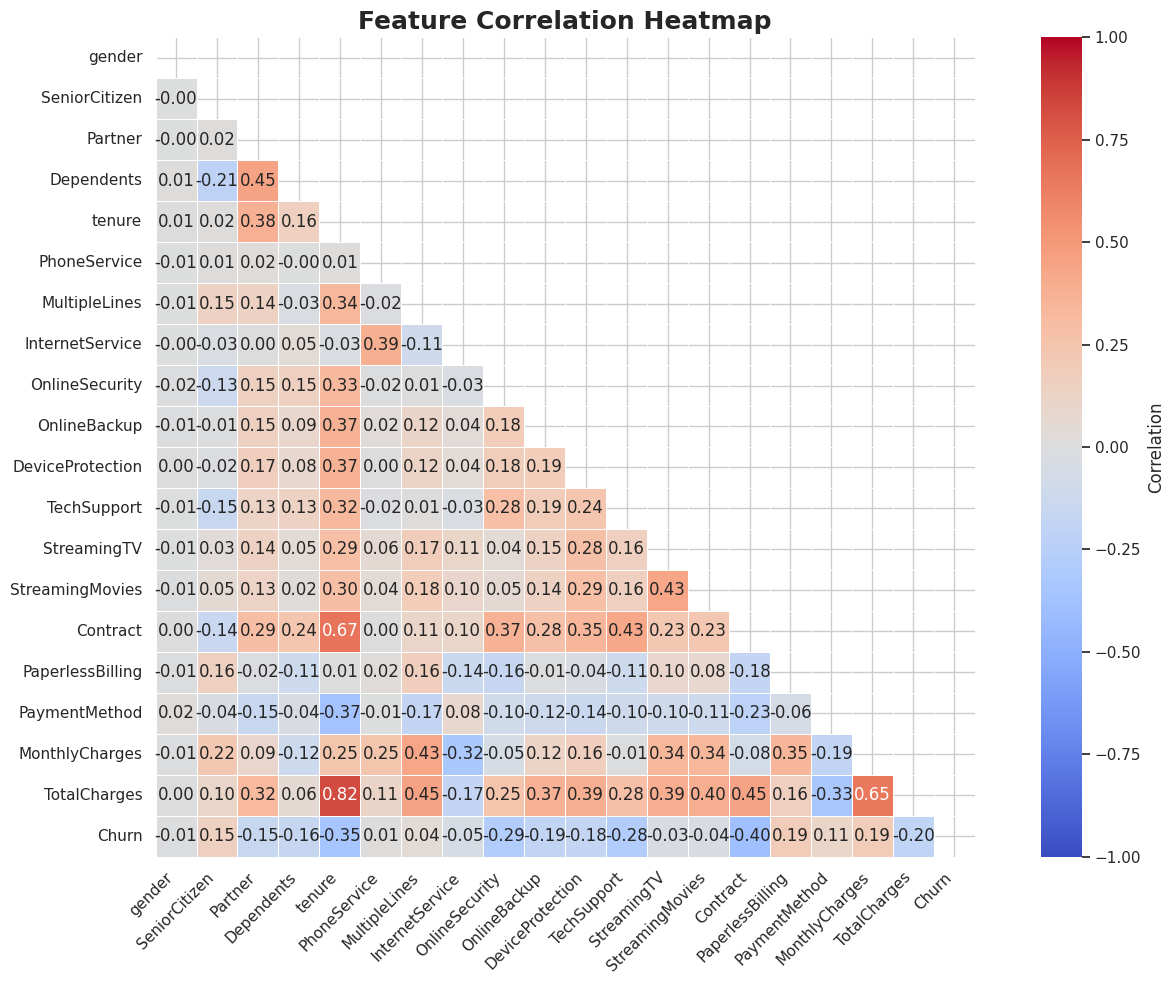

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_corr = df.copy()

for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

corr_matrix = df_corr.corr()

# Hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation Heatmap", fontsize=18, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ***Pairplot (Key Numerical Features)***

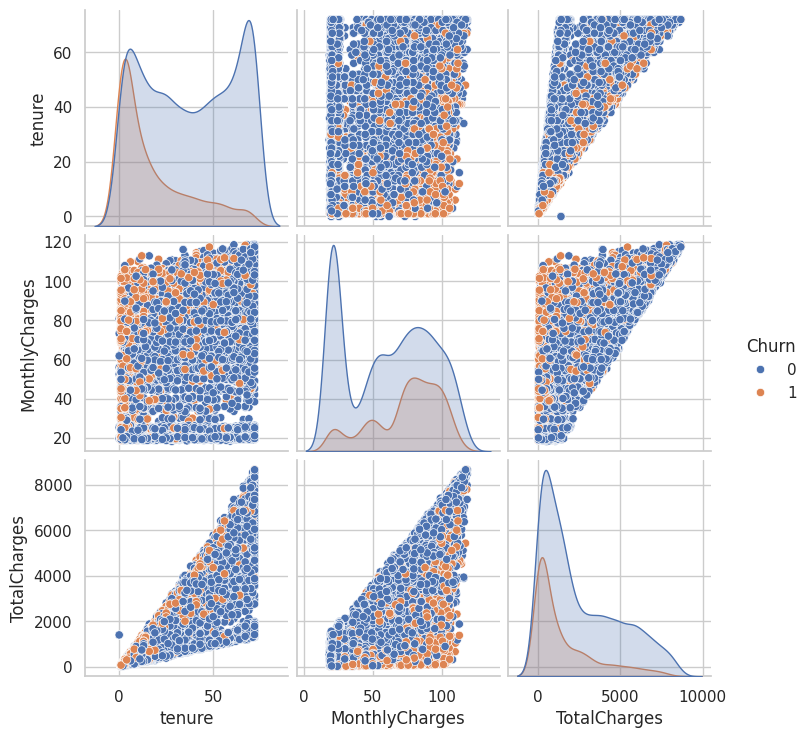

In [27]:
sns.pairplot(
    df,
    vars=["tenure","MonthlyCharges","TotalCharges"],
    hue="Churn"
)

plt.show()

This plot is called a **Pair Plot**. It is one of the most powerful EDA visualizations because it lets you analyze **multiple numerical variables simultaneously**.

---

# The Code

```python
sns.pairplot(
    df,
    vars=["tenure", "MonthlyCharges", "TotalCharges"],
    hue="Churn"
)

plt.show()
```

Let's understand it line by line.

---

## Line 1

```python
sns.pairplot(
```

Creates a **pairwise comparison plot**.

Instead of plotting just one graph, Seaborn creates **many graphs at once**.

---

## Line 2

```python
df,
```

Use the dataframe `df`.

---

## Line 3

```python
vars=["tenure","MonthlyCharges","TotalCharges"]
```

Only use these three numerical variables.

Without this line, Seaborn would plot **every numerical column**, which could create many unnecessary graphs.

Here it compares only:

* tenure
* MonthlyCharges
* TotalCharges

---

## Line 4

```python
hue="Churn"
```

This colors every point according to the target variable.

```text
Blue   → Churn = 0 (Stayed)

Orange → Churn = 1 (Left)
```

This helps us see whether churned customers form a different pattern.

---

# How PairPlot Works

Suppose we have three variables:

```text
tenure
MonthlyCharges
TotalCharges
```

Pairplot automatically creates:

|                | tenure                   | MonthlyCharges                 | TotalCharges                   |
| -------------- | ------------------------ | ------------------------------ | ------------------------------ |
| tenure         | Distribution             | tenure vs MonthlyCharges       | tenure vs TotalCharges         |
| MonthlyCharges | MonthlyCharges vs tenure | Distribution                   | MonthlyCharges vs TotalCharges |
| TotalCharges   | TotalCharges vs tenure   | TotalCharges vs MonthlyCharges | Distribution                   |

So with **3 variables**, it creates a **3 × 3 grid**.

---

# The Diagonal Plots

These graphs compare a variable **with itself**, so instead of scatterplots they show **distributions (KDE plots)**.

### Top-left

```
tenure
```

Shows the distribution of tenure.

You can see:

* Many customers have low tenure.
* Many customers also have very high tenure.

This matches the histogram you studied earlier.

---

### Middle

```
MonthlyCharges
```

Shows the distribution of monthly charges.

You can observe:

* Charges are spread across different values.
* Blue customers (stayed) appear more common overall.

---

### Bottom-right

```
TotalCharges
```

Shows the distribution of total charges.

Most customers have lower total charges, while fewer have very high total charges.

---

# Off-Diagonal Plots

These are **scatter plots** comparing two variables.

---

## 1. tenure vs MonthlyCharges

(Top-middle and middle-left)

Each dot represents **one customer**.

```
X-axis → MonthlyCharges

Y-axis → tenure
```

Observation:

Customers exist across almost all combinations.

There isn't a strong linear relationship.

---

## 2. tenure vs TotalCharges

(Top-right and bottom-left)

This is the most interesting plot.

Notice the triangular pattern.

```
Higher tenure
↓

Higher TotalCharges
```

As tenure increases,

TotalCharges also increase.

This makes sense because

```
TotalCharges ≈ MonthlyCharges × tenure
```

The longer a customer stays,

the more money they pay.

---

## 3. MonthlyCharges vs TotalCharges

(Middle-right and bottom-middle)

Again,

there is a positive relationship.

Customers with

* higher monthly bills

and

* longer tenure

naturally accumulate larger total charges.

---

# Why are there two identical scatterplots?

Notice

```
tenure vs TotalCharges
```

and

```
TotalCharges vs tenure
```

look the same.

That's because

```
X vs Y
```

is just the mirror image of

```
Y vs X
```

Pairplot automatically includes both.

---

# What does the color tell us?

Remember

```
Blue = Stayed

Orange = Churned
```

Look carefully.

You'll notice many orange points appear in

* lower tenure
* lower total charges

This supports what you found earlier using boxplots.

---

# Business Insights

From this pairplot, we can infer:

### 1.

Customers with **low tenure** are more likely to churn.

---

### 2.

Customers with **low TotalCharges** are also more likely to churn because they haven't stayed long enough to accumulate high charges.

---

### 3.

There is a strong positive relationship between

```
tenure
```

and

```
TotalCharges
```

which is expected because total charges accumulate over time.

---

### 4.

MonthlyCharges alone does not clearly separate churned and non-churned customers.

---

# Why use PairPlot?

Instead of making six or seven separate graphs, one `pairplot()` lets you:

* ✅ View the distribution of every selected variable.
* ✅ Study the relationship between every pair of variables.
* ✅ See how the target variable (`Churn`) is distributed across those relationships.

It's an excellent tool for getting an overall understanding of your data before building a machine learning model.

---

### Summary

| Part of PairPlot  | Purpose                                                        |
| ----------------- | -------------------------------------------------------------- |
| **Diagonal**      | Shows the distribution of each variable (using KDE/histogram). |
| **Off-diagonal**  | Shows the relationship between two variables (scatter plot).   |
| **Each dot**      | Represents one customer.                                       |
| **`hue="Churn"`** | Colors customers by churn status (Stayed vs Left).             |

For a churn prediction project, this plot quickly reveals that **tenure** and **TotalCharges** are closely related and that **customers with shorter tenure tend to churn more frequently**, making these features likely to be important for your predictive model.


# ***Business Summary Tables***



In [29]:
#Average Monthly Charges by Churn

print(
    df.groupby("Churn")["MonthlyCharges"].mean()
)

Churn
0    61.344878
1    74.604308
Name: MonthlyCharges, dtype: float64


In [30]:
#Average Tenure

print(
    df.groupby("Churn")["tenure"].mean()
)

Churn
0    37.640782
1    18.088853
Name: tenure, dtype: float64


In [31]:
#Average Total Charges

print(
    df.groupby("Churn")["TotalCharges"].mean()
)

Churn
0    2557.800857
1    1541.376548
Name: TotalCharges, dtype: float64


In [33]:
#Churn Rate by Category
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  57.357903  42.642097
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [36]:
#Save EDA Results (Optional)

contract_churn.to_csv("Contract_Churn_Rate.csv")

In [37]:
online_security = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(online_security)

Churn                        0          1
OnlineSecurity                           
No                   58.366762  41.633238
No internet service  92.791005   7.208995
Yes                  85.388806  14.611194


In [46]:
payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment)
print("Customers using Electronic Check have the highest churn rate (45%), suggesting this payment method is associated with a greater likelihood of customer attrition.")

Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.853752  45.146248
Mailed check               81.077694  18.922306
Customers using Electronic Check have the highest churn rate (45%), suggesting this payment method is associated with a greater likelihood of customer attrition.


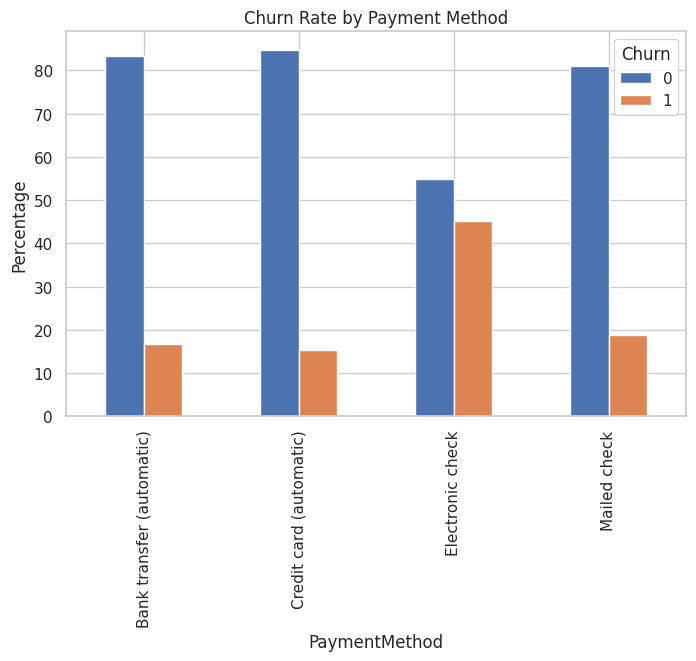

In [48]:
payment.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Payment Method")
plt.ylabel("Percentage")
plt.show()



## Unraveling the Mystery of Churn: Our Key Insights from the Data Odyssey!

Our journey through the customer churn data has been incredibly insightful, illuminating several critical patterns that drive customers away. These aren't just statistics; they're **powerful clues guiding us toward stronger retention strategies.**

#### The Unbreakable Link: Commitment is King (or Queen!)

**The most striking revelation? Contract type is the bedrock of customer loyalty!** Our analysis unequivocally shows that:

*   **Month-to-month contracts** are a churn magnet, with a staggering **42.6%** of these flexible customers waving goodbye. They're free birds, ready to fly at a moment's notice.
*   Conversely, **one-year contracts** see churn plummet to a mere **11.3%**.
*   And the ultimate loyalty test, **two-year contracts**, boast an astonishingly low churn rate of just **2.8%**! These customers are deeply invested, demonstrating remarkable stickiness.

This isn't just a correlation; it's a call to action: **encourage longer commitments!**

#### The Clock and the Coin: Tenure and Total Charges

It's no surprise, but deeply reinforced: **new customers are the most vulnerable.**

*   **Tenure tells a clear story:** Our churners tend to be fresh faces, averaging a mere **18 months** with us, while loyal customers stay for over **37 months**. They're leaving before they've even truly settled in.
*   This naturally leads to **Total Charges:** Churned customers have significantly lower lifetime value, accumulating around **$1,541** in total charges, compared to our steadfast customers who reach over **$2,557**. They're exiting before their true economic potential is realized.

#### The Price You Pay: Monthly Charges and Internet Service

Money talks, and sometimes it whispers 'goodbye':

*   Customers with **Fiber Optic internet** pay the highest monthly charges (a median of around **$90**) and, crucially, exhibit a **higher churn rate**. This suggests a potential pricing sensitivity or unmet expectations with premium services.
*   More broadly, customers who churn tend to have higher **Monthly Charges** (a median of **$74.60**) than those who stay (a median of **$61.34**). It seems a steeper bill can be a deal-breaker.

#### The Unexpected Vulnerabilities: Who Else is Leaving?

Our deep dive also unearthed specific segments demanding attention:

*   **Senior Citizens** are surprisingly more prone to churn, with **41.6%** leaving compared to **23.5%** of non-seniors. Are our services not catering to their unique needs?
*   **Online Security and Tech Support** act as vital anchors. Customers **without Online Security** show a high churn rate of **41.6%**, highlighting the importance of perceived digital safety.
*   The **Electronic Check payment method** is sounding an alarm, linked to a significant **45.1%** churn rate. This could indicate issues with the payment process itself or the demographic using it.

#### Where Do We Go From Here?

These insights are invaluable. While correlation is not causation, these **strong associations provide a clear roadmap**. We now know which customer segments are most at risk and which features are most indicative of their departure. This knowledge is our foundation for building predictive models, designing targeted retention campaigns, and ultimately, transforming our churn problem into a loyalty success story!
